# Model
Classification of animal pictures based + effect of imbalanced datasets.

**Authors**: Lenka Husárová, Martin Mislovič, Hana Magyarová

In [1]:
import os
import random
import shutil
import torch
import torch.nn as nn 
import torch.nn.functional as F
import torch.optim as optim 
import torchvision.transforms as transform 
from torchvision import datasets, transforms 
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, Subset, WeightedRandomSampler, random_split
import wandb
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
from collections import Counter, defaultdict
from sklearn.model_selection import train_test_split
from pathlib import Path
from tqdm import tqdm
from collections import defaultdict 

# Helper functions
In this section we define some helper functions for creating additional metrics / metric visualisations.

## Confusion Matrix

In [2]:
# function to draw confusion matrix
def plot_confusion_matrix(cm, classes):
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=classes, yticklabels=classes)
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

## Top *k* accuracy

In [3]:
# function that computes top1 and top5 score
def top_k_accuracy(output, target, topk=(1, 5)):
    with torch.no_grad():
        maxk = max(topk)
        batch_size = target.size(0)

        _, pred = output.topk(maxk, dim=1, largest=True, sorted=True)
        pred = pred.t()
        correct = pred.eq(target.view(1, -1).expand_as(pred))

        accuracies = []
        for k in topk:
            correct_k = correct[:k].reshape(-1).float().sum(0)
            accuracies.append((correct_k / batch_size).item())
        return accuracies  # returns list [top1_acc, top5_acc]

# Loading in the data
In this section we describe the proces used to load in the data.

## BalancerWrapper
Wrapper around the original dataset that helps to balance it either by using undersampling or oversampling

In [4]:
class BalancerWrapper(torch.utils.data.Dataset):
    def __init__(self, base_dataset, transform=None, mode="oversample"):
        self.base_dataset = base_dataset
        self.transform = transform

        self.class_counts = defaultdict(int)
        for _, label in self.base_dataset:
            self.class_counts[label] += 1

        if mode == "oversample":
            self.class_size = max(self.class_counts.values())
        elif mode == "undersample":
            self.class_size = min(self.class_counts.values())

        self.class_images = {}
        for index, (_, label) in enumerate(self.base_dataset):
            if label not in self.class_images:
                self.class_images[label] = []
            self.class_images[label].append(index)

        self.balanced_indices = []

        for label, indices in self.class_images.items():
            if len(indices) < self.class_size:
                to_add: int = self.class_size - len(indices)
                indices.extend(random.choices(indices, k=to_add))
                #indices = indices * (self.max_class_size // len(indices)) + indices[:self.max_class_size % len(indices)]
            if len(indices) > self.class_size:
                indices = random.sample(indices, k=self.class_size)
            self.balanced_indices.extend(indices)

    
    def __len__(self):
        return len(self.balanced_indices)
    

    def __getitem__(self, index):
        image_index = self.balanced_indices[index]
        image, label = self.base_dataset[image_index]

        if self.transform is not None:
            image = self.transform(image)

        return image, label
    

## TransformWrapper
Simple wrapper applying transform to the dataset. This code is unchanged to mentain compatibility with the other teams for comparison

In [5]:
class TransformWrapper(torch.utils.data.Dataset):
    def __init__(self, subset, transform):
        self.subset = subset
        self.transform = transform

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        img, label = self.subset[idx]
        img = self.transform(img)
        return img, label

## DataModule
Helper class wrapping all the data loading and transformations into one class. Seed and transformations used for the test and validation dataset are identical to other teams for comparison.

In [7]:
class DataModule:
    def __init__(self, img_path: str = "data/raw-img", seed=20, mode="oversampling"):
        self.transform_train = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.RandomHorizontalFlip(),
            transforms.RandomRotation(30),
            transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.2),
            transforms.RandomAffine(degrees=10, translate=(0.1, 0.1)),
            transforms.ToTensor(),
            transforms.Normalize(
                mean=[0.5106, 0.4826, 0.3987],
                std=[0.2179, 0.2174, 0.2166]),
        ])

        ### Neupravovat ###
        self.transforms_val_test = transforms.Compose([
            transforms.Resize(256),
            transforms.CenterCrop(224),
            transforms.ToTensor(),
            transforms.Normalize(
                mean=[0.5106, 0.4826, 0.3987],
                std=[0.2179, 0.2174, 0.2166]),
        ])
        ### ----------- ###

        data = ImageFolder(root=img_path)
        self.full_dataset = data
        generator = torch.Generator().manual_seed(seed)
        data_size = len(data)
        train_size = int(0.7 * data_size) 
        val_size = int(0.15 * data_size) 
        test_size = data_size - train_size - val_size 

        train_split, val_split, test_split = random_split(
            data, [train_size, val_size, test_size], generator=generator
        )
        
        if mode == "undersampling":
            self.train_dataset = BalancerWrapper(train_split, self.transform_train, mode="undersample")
        elif mode == "oversampling":
            self.train_dataset = BalancerWrapper(train_split, self.transform_train, mode="oversample")
        else:
            self.train_dataset = TransformWrapper(train_split, self.transform_train)

        self.val_dataset = TransformWrapper(val_split, self.transforms_val_test)
        self.test_dataset = TransformWrapper(test_split, self.transforms_val_test)

    def get_classes(self):
        return self.full_dataset.classes

    def get_train_dataset(self):
        return self.train_dataset
    

    def get_val_dataset(self):
        return self.val_dataset
    

    def get_test_dataset(self):
        return self.test_dataset
    

    def print_class_counts(self):
        class_counts = defaultdict(int)
        for _, label in self.train_dataset:
            class_counts[label] += 1
        for label, count in class_counts.items():
            print(f"{label}: {count}")
    

    def create_dataloaders(self, batch_size: int):
        train_loader = DataLoader(self.train_dataset, batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(self.val_dataset, batch_size=batch_size, shuffle=False)
        test_loader = DataLoader(self.test_dataset , batch_size=batch_size, shuffle=False)
        return train_loader, val_loader, test_loader

# Models
In this section we define several models we experimented with over the course of this project

## AlexNet
We started with basic AlexNet network.

In [8]:
class AlexNet(nn.Module):
    def __init__(self, num_classes):
        super(AlexNet, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=96, kernel_size=11, stride=4),
            nn.BatchNorm2d(num_features=96),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2),
            nn.Conv2d(in_channels=96, out_channels=256, kernel_size=5, padding=2),
            nn.BatchNorm2d(num_features=256),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2),
            nn.Conv2d(in_channels=256, out_channels=384, kernel_size=3, padding=1),
            nn.BatchNorm2d(num_features=384),
            nn.ReLU(),
            nn.Conv2d(in_channels=384, out_channels=384, kernel_size=3, padding=1),
            nn.BatchNorm2d(num_features=384),
            nn.ReLU(),
            nn.Conv2d(in_channels=384, out_channels=256, kernel_size=3, padding=1),
            nn.BatchNorm2d(num_features=256),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2),
        )
        self.fc = nn.Sequential(
            nn.Linear(in_features=256 * 5 * 5, out_features=4096),
            nn.BatchNorm1d(num_features=4096),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(in_features=4096, out_features=4096),
            nn.BatchNorm1d(num_features=4096),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(in_features=4096, out_features=10),
            nn.Softmax(dim=1),
        )

    def forward(self, x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

## SimpleNet
We modified our initial AlexNet model into more refined network we called the SimpleNet.

In [816]:
class SimpleNet(nn.Module):
    def __init__(self, num_classes):
        super(SimpleNet, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=96, kernel_size=11, stride=4),
            nn.BatchNorm2d(num_features=96),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2),

            nn.Conv2d(in_channels=96, out_channels=256, kernel_size=5, padding=2),
            nn.BatchNorm2d(num_features=256),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2),

            nn.Conv2d(in_channels=256, out_channels=384, kernel_size=3, padding=1),
            nn.BatchNorm2d(num_features=384),
            nn.ReLU(),
            nn.Conv2d(in_channels=384, out_channels=384, kernel_size=3, padding=1),
            nn.BatchNorm2d(num_features=384),
            nn.ReLU(),
            nn.Conv2d(in_channels=384, out_channels=256, kernel_size=3, padding=1),
            nn.BatchNorm2d(num_features=256),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2),
        )
        self.fc = nn.Sequential(
            nn.Linear(in_features=256 * 5 * 5, out_features=2048),
            nn.BatchNorm1d(num_features=2048),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(in_features=2048, out_features=512),
            nn.BatchNorm1d(num_features=512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(in_features=512, out_features=10),
            nn.Softmax(dim=1),
        )

    def forward(self, x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

## SimpleNetV3
This model represents the final refinement of SimpleNet. Our initial SimpleNet performed well on undersampled dataset but strugled to extract more information from the oversampled set. This new version adresses these concerns with slightly modified convolution layer size - smaller kernels at the start and more channels at the end. Furthermore this version uses a more pooling layers as well as global average pooling to give the classification head as much information as possible. Additionally standard ReLU activations were replaced with LeakyReLU to further increase performance.

The classification head was further simplified to reduce overfitting. This version also incorporates dropout between the convolutional layers to reduce the overfitting which was a significant issue with the initial architecture.

Resulting model performs significantly better on the oversampled dataset at the cost of slower learning proces

In [9]:
class SimpleNetV3(nn.Module):
    def __init__(self):
        super(SimpleNetV3, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=64, kernel_size=5, stride=2, padding=2),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.1),
            nn.Dropout2d(0.1),
            nn.MaxPool2d(kernel_size=3, stride=2),

            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.1),
            nn.Dropout2d(0.2),
            nn.MaxPool2d(kernel_size=3, stride=2),

            nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.1),
            nn.Dropout2d(0.3),
            nn.Conv2d(in_channels=256, out_channels=256, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.1),
            nn.MaxPool2d(kernel_size=3, stride=2),

            nn.Conv2d(in_channels=256, out_channels=512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.1),
            nn.AdaptiveAvgPool2d((1,1))
        )
        self.fc = nn.Sequential(
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(0.1),
            nn.Dropout(0.5),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

# Device selection
Selects the device to use based on what is the best thing aviable

In [10]:
if torch.cuda.is_available():
    print("Currently using: Nvidia CUDA")
    device = torch.device("cuda")
elif torch.mps.is_available():
    print("Currently using: Apple Metal Performance Shaders")
    device = torch.device("mps")
else:
    print("Currently using: CPU")
    device = torch.device("cpu")

Currently using: Nvidia CUDA


## Trainer
We defined a helper trainer class to manage training and testing the models

In [11]:
class Trainer:
    def __init__(self, datamodule: DataModule, batch_size: int = 64, use_wandb: bool = True):
        self.datamodule = datamodule
        self.use_wandb = use_wandb
        self.train_loader, self.val_loader, self.test_loader = self.datamodule.create_dataloaders(batch_size)
    
    def get_class_names(self):
        if hasattr(self.train_loader.dataset, "classes"):
            return self.train_loader.dataset.classes
        else:
            raise AttributeError("dataset has no classes attribute'")


    def train(self, model, loss_function, optimizer, learning_rate_scheduler = None, epochs: int = 1, name=""):
        classes = self.datamodule.get_classes()
        for epoch in range(epochs):
            model.train()
            running_loss = 0.0
            all_preds = []
            all_labels = []
            with tqdm(self.train_loader, desc=f"Train: {epoch + 1}") as progress:
                for inputs, labels in progress:
                    inputs, labels = inputs.to(device), labels.to(device)

                    optimizer.zero_grad()
                    outputs = model(inputs)
                    loss = loss_function(outputs, labels)
                    loss.backward()
                    optimizer.step()

                    running_loss += loss.item()
                    _, predicted = torch.max(outputs.data, 1)
                    #total += labels.size(0)
                    #correct += (predicted == labels).sum().item()

                    # collecting predictions and labels for later metrics computation
                    all_preds.extend(predicted.cpu().numpy())
                    all_labels.extend(labels.cpu().numpy())


            # compute additional metrics
            precision = precision_score(all_labels, all_preds, average='macro', zero_division=0)
            recall = recall_score(all_labels, all_preds, average='macro', zero_division=0)
            f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
            acc = accuracy_score(all_labels, all_preds)
            
            print(f"epoch {epoch+1}/{epochs}, loss: {running_loss / len(self.train_loader):.4f}")
            print(f"accuracy: {acc*100:.2f}%, precision: {precision:.4f}, recall: {recall:.4f}, f1: {f1:.4f}")

            model.eval()
            val_loss = 0.0
            val_all_preds = []
            val_all_labels = []
            val_top1_total = 0.0
            val_top5_total = 0.0
            with torch.no_grad():
                with tqdm(self.val_loader, desc=f"Validation: {epoch + 1}") as progress:
                    for inputs, labels in progress:
                        inputs, labels = inputs.to(device), labels.to(device)
                        outputs = model(inputs)
                        loss = loss_function(outputs, labels)
                        val_loss += loss.item()
                        _, predicted = torch.max(outputs.data, 1)
                        #val_total += labels.size(0)
                        #val_correct += (predicted == labels).sum().item()
                        # top1 and top5 metrics
                        top1, top5 = top_k_accuracy(outputs, labels, topk=(1, 5))
                        val_top1_total += top1
                        val_top5_total += top5

                        # collecting predictions and labels for later metrics computation
                        val_all_preds.extend(predicted.cpu().numpy())
                        val_all_labels.extend(labels.cpu().numpy())

            # compute additional metrics for validation
            val_precision = float(precision_score(val_all_labels, val_all_preds, average='macro', zero_division=0))
            val_recall = float(recall_score(val_all_labels, val_all_preds, average='macro', zero_division=0))
            val_f1 = float(f1_score(val_all_labels, val_all_preds, average='macro', zero_division=0))
            val_acc = float(accuracy_score(val_all_labels, val_all_preds))
            
            # top1 and top5
            avg_top1 = float(100 * val_top1_total / len(self.val_loader))
            avg_top5 = float(100 * val_top5_total / len(self.val_loader))

            if self.use_wandb:
                wandb.log({
                    "epoch": epoch,
                    "train_loss": running_loss / len(self.train_loader),
                    "train_accuracy": acc,
                    "train_precision": precision,
                    "train_recall": recall,
                    "train_f1": f1,
                    "val_loss": val_loss / len(self.val_loader),
                    "val_accuracy": val_acc,
                    "val_precision": val_precision,
                    "val_recall": val_recall,
                    "val_f1": val_f1,
                    "val_top1": avg_top1,
                    "val_top5": avg_top5
                })
#
            print(f"validation top-1 accuracy: {avg_top1:.2f}%")
            print(f"validation top-5 accuracy: {avg_top5:.2f}%")
            print(f"validation accuracy: {val_acc*100:.2f}%")
            print(f"validation precision: {val_precision:.4f}, recall: {val_recall:.4f}, f1: {val_f1:.4f}")
            
            if learning_rate_scheduler is not None:
                learning_rate_scheduler.step()

        cm = confusion_matrix(val_all_labels, val_all_preds)
        plot_confusion_matrix(cm, classes=classes)
    

    def test(self, model):
        classes = self.datamodule.get_classes()
        model.eval()
        test_all_preds = []
        test_all_labels = []
        test_top1_total = 0.0
        test_top5_total = 0.0
        with torch.no_grad():
            for inputs, labels in self.test_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                _, predicted = torch.max(outputs.data, 1)
                #test_total += labels.size(0)
                #test_correct += (predicted == labels).sum().item()
                # top-1 and top-5 accuracy
                top1, top5 = top_k_accuracy(outputs, labels, topk=(1, 5))
                test_top1_total += top1
                test_top5_total += top5
                # collecting predictions and labels for later metrics computation
                test_all_preds.extend(predicted.cpu().numpy())
                test_all_labels.extend(labels.cpu().numpy())

        # compute additional metrics for test
        test_precision = precision_score(test_all_labels, test_all_preds, average='macro', zero_division=0)
        test_recall = recall_score(test_all_labels, test_all_preds, average='macro', zero_division=0)
        test_f1 = f1_score(test_all_labels, test_all_preds, average='macro', zero_division=0)
        test_acc = accuracy_score(test_all_labels, test_all_preds)
        avg_top1_test = 100 * test_top1_total / len(self.test_loader)
        avg_top5_test = 100 * test_top5_total / len(self.test_loader)

        # print test metrics
        print(f"\ntest Accuracy: {test_acc*100:.2f}%")
        print(f"test Precision: {test_precision:.4f}, recall: {test_recall:.4f}, f1: {test_f1:.4f}")
        print(f"test Top-1 Accuracy: {avg_top1_test:.2f}%")
        print(f"test Top-5 Accuracy: {avg_top5_test:.2f}%")

        # log to wandb
        if self.use_wandb:
            wandb.log({
                "test_accuracy": test_acc,
                "test_precision": test_precision,
                "test_recall": test_recall,
                "test_f1_score": test_f1,
                "test_top1": avg_top1_test,
                "test_top5": avg_top5_test
            })
        
        # confusion Matrix for test data
        cm_test = confusion_matrix(test_all_labels, test_all_preds)
        plot_confusion_matrix(cm_test, classes=classes)
        

# Experimentation with models
In this section we experiment with different models. Due to very long training times, runs in this section are limited to 10 epochs on the undersampled dataset.

## Test run of AlexNet
We started our experimentation with basic AlexNet model.

In [820]:
wandb.login(key="5daf9435f17e66f67096e620807baf464d85f5cd")
wandb.init(project="NN-2", entity="xmagyarova-stu")

wandb: WARNING Calling wandb.login() after wandb.init() has no effect.


epoch,▁▂▃▃▄▅▆▆▇█
train_accuracy,▁▂▄▄▅▆▆▇██
train_f1,▁▂▃▄▅▅▆▇██
train_loss,█▆▅▅▄▃▃▂▂▁
train_precision,▁▂▃▄▅▅▆▇██
train_recall,▁▂▄▄▅▆▆▇██
val_accuracy,▁▂▃▃▄▅▆▆▆█
val_f1,▁▂▃▃▄▅▆▆▆█
val_loss,█▇▅▅▅▄▂▂▂▁
val_precision,▁▂▆▅▅▆▆█▇█
val_recall,▁▂▃▃▃▅▆▇▇█


In [821]:
model_alex = AlexNet(num_classes=10).to(device)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(model_alex.parameters(), lr=0.0001, weight_decay=0.1)

datamodule = DataModule(mode="undersampling")
trainer = Trainer(datamodule, batch_size=64)

learning_rate_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

Train: 1: 100%|██████████| 157/157 [01:01<00:00,  2.56it/s]


epoch 1/10, loss: 2.1948
accuracy: 26.99%, precision: 0.2496, recall: 0.2699, f1: 0.2398


Validation: 1: 100%|██████████| 62/62 [00:11<00:00,  5.31it/s]


validation top-1 accuracy: 26.47%
validation top-5 accuracy: 77.80%
validation accuracy: 26.36%
validation precision: 0.2647, recall: 0.3161, f1: 0.2451


Train: 2: 100%|██████████| 157/157 [01:00<00:00,  2.58it/s]


...

validation top-1 accuracy: 55.14%
validation top-5 accuracy: 92.11%
validation accuracy: 55.09%
validation precision: 0.5550, recall: 0.5589, f1: 0.5431


Train: 10: 100%|██████████| 157/157 [01:00<00:00,  2.61it/s]


epoch 10/10, loss: 1.9293
accuracy: 57.78%, precision: 0.5739, recall: 0.5778, f1: 0.5748


Validation: 10: 100%|██████████| 62/62 [00:10<00:00,  5.70it/s]


validation top-1 accuracy: 53.47%
validation top-5 accuracy: 92.01%
validation accuracy: 53.36%
validation precision: 0.5511, recall: 0.5520, f1: 0.5308


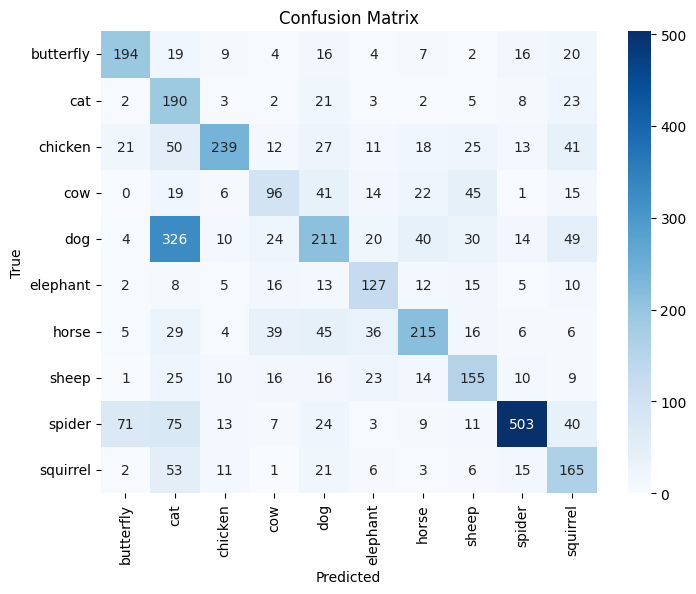

In [822]:
trainer.train(model_alex, criterion, optimizer, learning_rate_scheduler,epochs=10)


test Accuracy: 53.82%
test Precision: 0.5533, recall: 0.5540, f1: 0.5335
test Top-1 Accuracy: 53.70%
test Top-5 Accuracy: 92.53%


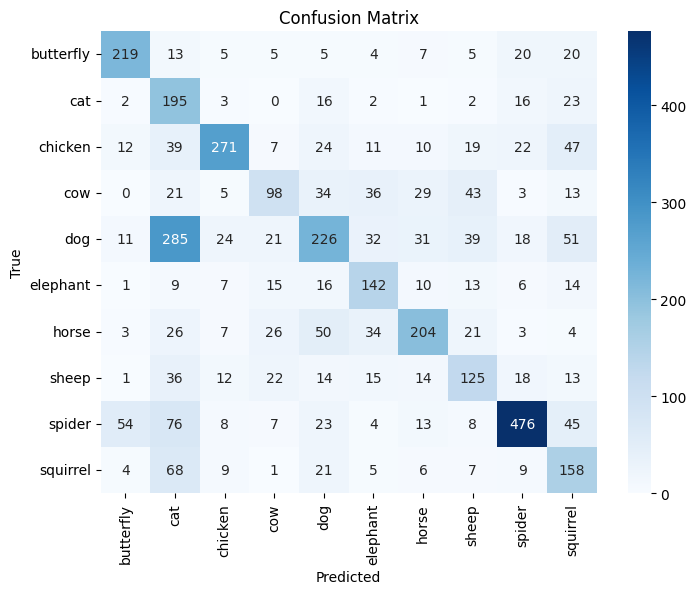

In [823]:
trainer.test(model_alex)

In [824]:
wandb.finish()

epoch,▁▂▃▃▄▅▆▆▇█
test_accuracy,▁
test_f1_score,▁
test_precision,▁
test_recall,▁
test_top1,▁
test_top5,▁
train_accuracy,▁▃▄▅▅▇▇███
train_f1,▁▃▄▅▅▇▇███
train_loss,█▆▅▄▄▂▂▁▁▁
train_precision,▁▃▄▅▅▇▇███


## Test run of SimpleNet

In [825]:
wandb.login(key="5daf9435f17e66f67096e620807baf464d85f5cd")
wandb.init(project="NN-2", entity="xmagyarova-stu")

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: Appending key for api.wandb.ai to your netrc file: C:\Users\marti\_netrc


In [826]:
model_simple = SimpleNet(num_classes=10).to(device)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(model_simple.parameters(), lr=0.0001, weight_decay=0.1)

datamodule = DataModule(mode="undersampling")
trainer = Trainer(datamodule, batch_size=64)

learning_rate_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

Train: 1: 100%|██████████| 157/157 [01:05<00:00,  2.39it/s]


epoch 1/10, loss: 2.2070
accuracy: 27.44%, precision: 0.2508, recall: 0.2744, f1: 0.2488


Validation: 1: 100%|██████████| 62/62 [00:12<00:00,  4.86it/s]


validation top-1 accuracy: 25.21%
validation top-5 accuracy: 77.80%
validation accuracy: 25.09%
validation precision: 0.3241, recall: 0.2731, f1: 0.2099


Train: 2: 100%|██████████| 157/157 [01:00<00:00,  2.61it/s]


...

validation top-1 accuracy: 57.48%
validation top-5 accuracy: 92.85%
validation accuracy: 57.41%
validation precision: 0.5806, recall: 0.5929, f1: 0.5686


Train: 10: 100%|██████████| 157/157 [00:59<00:00,  2.63it/s]


epoch 10/10, loss: 1.9133
accuracy: 61.62%, precision: 0.6122, recall: 0.6162, f1: 0.6129


Validation: 10: 100%|██████████| 62/62 [00:11<00:00,  5.40it/s]


validation top-1 accuracy: 58.89%
validation top-5 accuracy: 93.42%
validation accuracy: 58.84%
validation precision: 0.5864, recall: 0.6011, f1: 0.5772


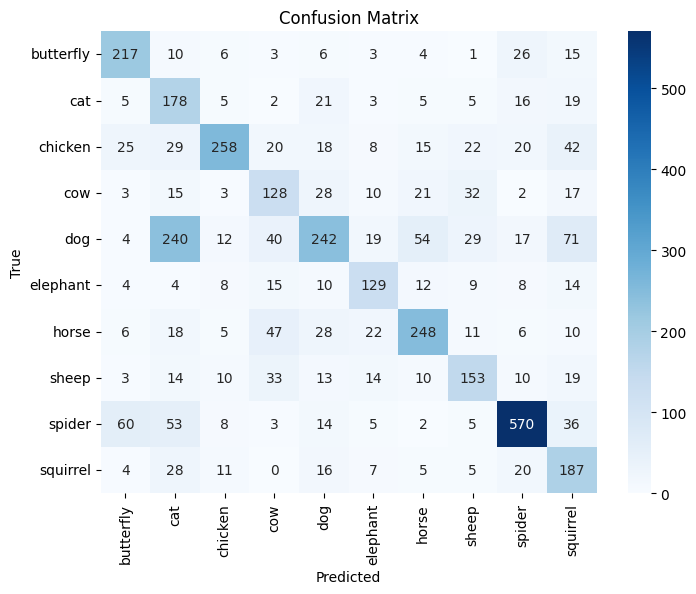

In [827]:
trainer.train(model_simple, criterion, optimizer, learning_rate_scheduler,epochs=10)


test Accuracy: 59.57%
test Precision: 0.6003, recall: 0.6127, f1: 0.5886
test Top-1 Accuracy: 59.48%
test Top-5 Accuracy: 93.10%


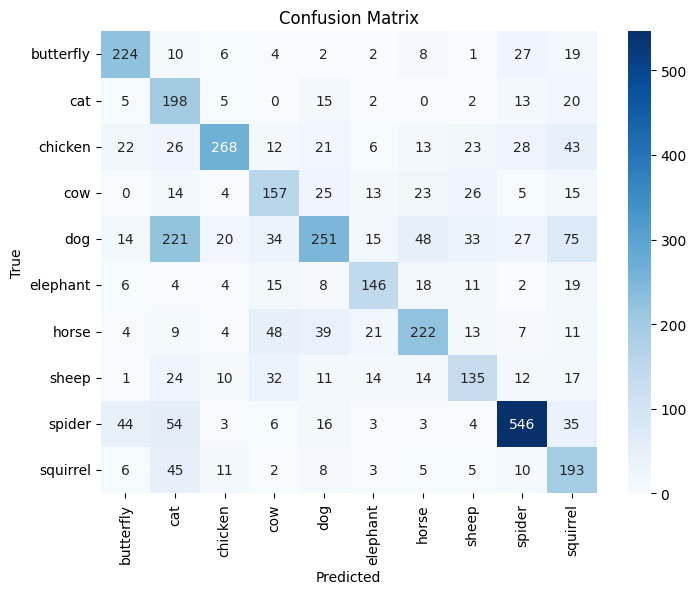

In [828]:
trainer.test(model_simple)

In [829]:
wandb.finish()

epoch,▁▂▃▃▄▅▆▆▇█
test_accuracy,▁
test_f1_score,▁
test_precision,▁
test_recall,▁
test_top1,▁
test_top5,▁
train_accuracy,▁▃▄▅▆▇▇███
train_f1,▁▃▄▅▆▇▇███
train_loss,█▆▅▄▃▂▂▁▁▁
train_precision,▁▅▄▅▆▇▇███


We can see that our improved SimpleNet outperformed basic AlexNet by about 5%

# Final runs with SimpleNetV3
Final runs were done with the SimpleNetV3 dataset.

## Undersampled dataset

In [830]:
DataModule(mode="undersampling").print_class_counts()

6: 1000
7: 1000
5: 1000
3: 1000
0: 1000
2: 1000
8: 1000
1: 1000
4: 1000
9: 1000


In [12]:
# initialize wandb
wandb.login(key="5daf9435f17e66f67096e620807baf464d85f5cd")
wandb.init(project="NN-2", entity="xmagyarova-stu")

wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: Appending key for api.wandb.ai to your netrc file: C:\Users\marti\_netrc
wandb: Currently logged in as: xmagyarova (xmagyarova-stu) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [13]:
model_simple_v3_under = SimpleNetV3().to(device)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(model_simple_v3_under.parameters(), lr=0.0001, weight_decay=0.1)

datamodule = DataModule(mode="undersampling")
trainer = Trainer(datamodule, batch_size=64)

learning_rate_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=60, eta_min=1e-5)

Train: 1: 100%|██████████| 157/157 [01:04<00:00,  2.44it/s]


epoch 1/60, loss: 2.3087
accuracy: 15.79%, precision: 0.1551, recall: 0.1579, f1: 0.1537


Validation: 1: 100%|██████████| 62/62 [00:13<00:00,  4.66it/s]


validation top-1 accuracy: 21.39%
validation top-5 accuracy: 70.48%
validation accuracy: 21.47%
validation precision: 0.2222, recall: 0.1599, f1: 0.1266


Train: 2: 100%|██████████| 157/157 [01:01<00:00,  2.53it/s]


...

validation top-1 accuracy: 64.66%
validation top-5 accuracy: 96.22%
validation accuracy: 64.62%
validation precision: 0.6464, recall: 0.6588, f1: 0.6388


Train: 60: 100%|██████████| 157/157 [00:55<00:00,  2.81it/s]


epoch 60/60, loss: 1.3484
accuracy: 63.52%, precision: 0.6327, recall: 0.6352, f1: 0.6334


Validation: 60: 100%|██████████| 62/62 [00:09<00:00,  6.27it/s]


validation top-1 accuracy: 64.88%
validation top-5 accuracy: 96.14%
validation accuracy: 64.80%
validation precision: 0.6412, recall: 0.6563, f1: 0.6378


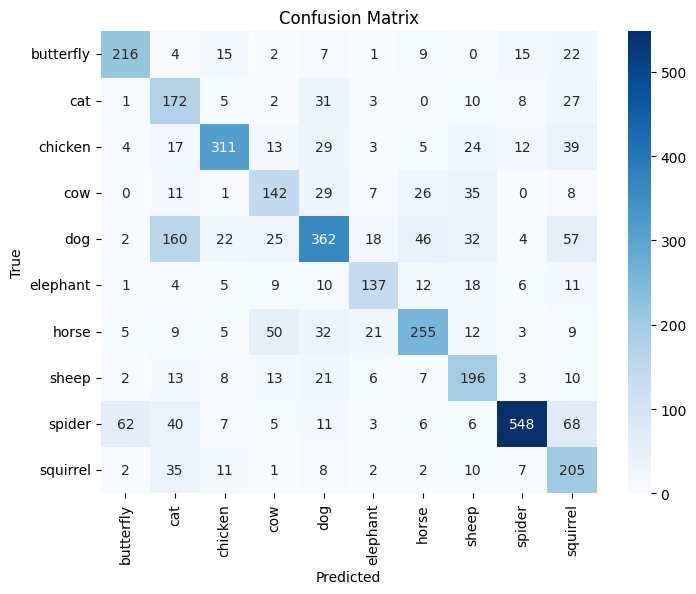

In [14]:
trainer.train(model_simple_v3_under, criterion, optimizer, learning_rate_scheduler,epochs=60)


test Accuracy: 65.84%
test Precision: 0.6560, recall: 0.6774, f1: 0.6533
test Top-1 Accuracy: 65.68%
test Top-5 Accuracy: 96.05%


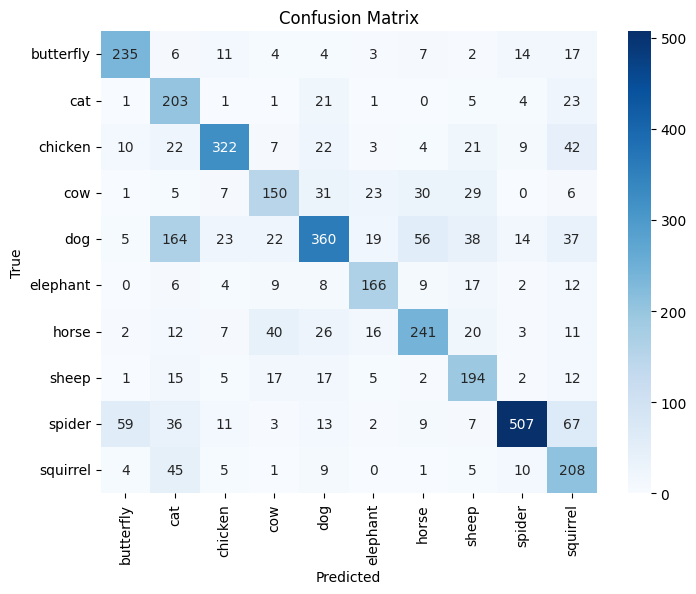

In [15]:
trainer.test(model_simple_v3_under)

In [16]:
wandb.finish()

epoch,▁▁▁▁▁▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇████
test_accuracy,▁
test_f1_score,▁
test_precision,▁
test_recall,▁
test_top1,▁
test_top5,▁
train_accuracy,▁▂▂▂▃▃▃▄▄▄▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇██████████
train_f1,▁▂▂▂▃▄▄▄▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇████████████
train_loss,█▇▇▇▆▅▅▅▄▄▄▄▄▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁
train_precision,▁▂▂▃▃▄▄▅▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇███████████


## Oversampling dataset

In [17]:
DataModule(mode="oversampling").print_class_counts()

6: 3397
7: 3397
5: 3397
3: 3397
0: 3397
2: 3397
8: 3397
1: 3397
4: 3397
9: 3397


In [18]:
# initialize wandb
wandb.login(key="5daf9435f17e66f67096e620807baf464d85f5cd")
wandb.init(project="NN-2", entity="xmagyarova-stu")

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: Appending key for api.wandb.ai to your netrc file: C:\Users\marti\_netrc


In [19]:
model_simple_v3_over = SimpleNetV3().to(device)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(model_simple_v3_over.parameters(), lr=0.0001, weight_decay=0.1)

datamodule = DataModule(mode="oversampling")
trainer = Trainer(datamodule, batch_size=64)

learning_rate_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=60, eta_min=1e-5)

Train: 1: 100%|██████████| 531/531 [03:20<00:00,  2.65it/s]


epoch 1/60, loss: 2.1993
accuracy: 21.70%, precision: 0.2076, recall: 0.2170, f1: 0.2092


Validation: 1: 100%|██████████| 62/62 [00:10<00:00,  5.95it/s]


validation top-1 accuracy: 24.91%
validation top-5 accuracy: 75.54%
validation accuracy: 24.83%
validation precision: 0.3134, recall: 0.2564, f1: 0.1980


Train: 2: 100%|██████████| 531/531 [03:09<00:00,  2.80it/s]


...

validation top-1 accuracy: 80.27%
validation top-5 accuracy: 98.31%
validation accuracy: 80.16%
validation precision: 0.7918, recall: 0.7984, f1: 0.7898


Train: 60: 100%|██████████| 531/531 [03:36<00:00,  2.45it/s]


epoch 60/60, loss: 0.9799
accuracy: 81.88%, precision: 0.8180, recall: 0.8188, f1: 0.8182


Validation: 60: 100%|██████████| 62/62 [00:10<00:00,  5.69it/s]


validation top-1 accuracy: 81.18%
validation top-5 accuracy: 98.26%
validation accuracy: 81.07%
validation precision: 0.8022, recall: 0.7994, f1: 0.7969


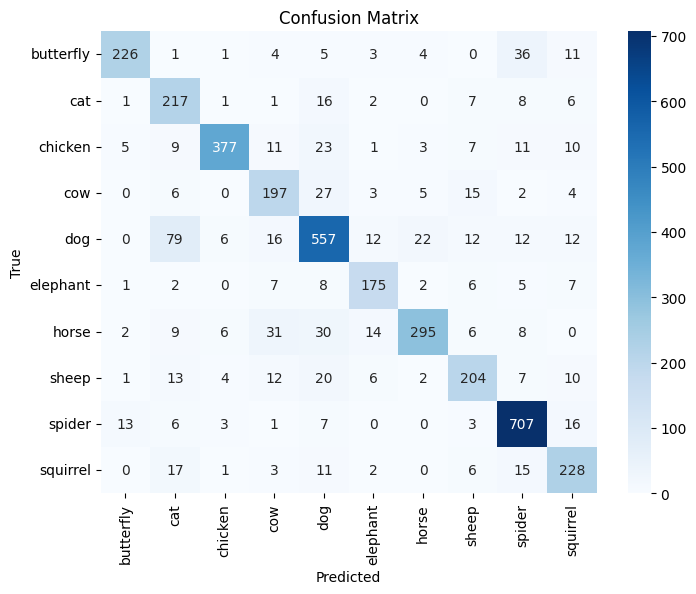

In [20]:
trainer.train(model_simple_v3_over, criterion, optimizer, learning_rate_scheduler, epochs=60)


test Accuracy: 80.96%
test Precision: 0.8040, recall: 0.8019, f1: 0.7997
test Top-1 Accuracy: 80.94%
test Top-5 Accuracy: 98.16%


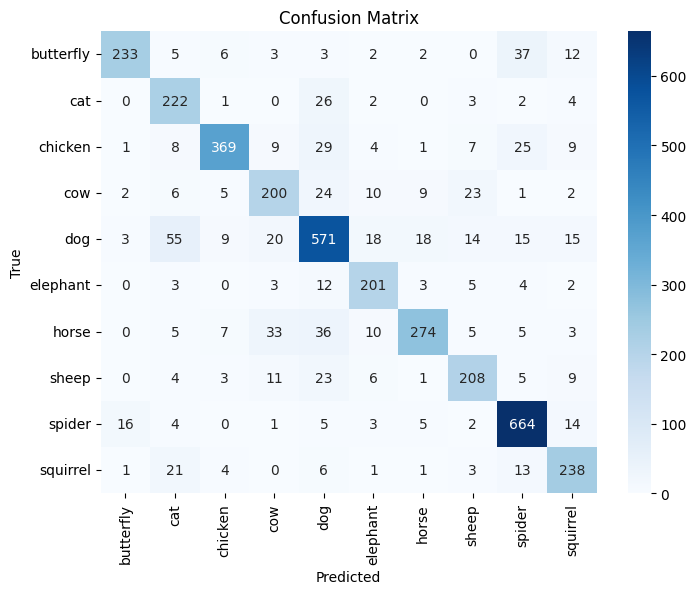

In [21]:
trainer.test(model_simple_v3_over)

In [22]:
wandb.finish()

epoch,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇███
test_accuracy,▁
test_f1_score,▁
test_precision,▁
test_recall,▁
test_top1,▁
test_top5,▁
train_accuracy,▁▃▄▄▄▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇██████████████
train_f1,▁▂▃▃▄▄▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇██████████████
train_loss,█▇▆▆▅▅▅▄▄▄▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁
train_precision,▁▃▄▄▄▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇███████████████


## Original inbalanced dataset

In [23]:
DataModule(mode="normal").print_class_counts()

6: 1844
7: 1271
5: 1000
3: 1325
0: 1518
2: 2179
8: 3351
1: 1149
4: 3397
9: 1291


In [24]:
# initialize wandb
wandb.login(key="5daf9435f17e66f67096e620807baf464d85f5cd")
wandb.init(project="NN-2", entity="xmagyarova-stu")

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: Appending key for api.wandb.ai to your netrc file: C:\Users\marti\_netrc


In [25]:
model_simple_v3_inbalanced = SimpleNetV3().to(device)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(model_simple_v3_inbalanced.parameters(), lr=0.0001, weight_decay=0.1)

datamodule = DataModule(mode="normal")
trainer = Trainer(datamodule, batch_size=64)

learning_rate_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=60, eta_min=1e-5)

Train: 1: 100%|██████████| 287/287 [01:43<00:00,  2.76it/s]


epoch 1/60, loss: 2.2015
accuracy: 23.00%, precision: 0.1688, recall: 0.1707, f1: 0.1609


Validation: 1: 100%|██████████| 62/62 [00:09<00:00,  6.27it/s]


validation top-1 accuracy: 26.70%
validation top-5 accuracy: 72.04%
validation accuracy: 26.80%
validation precision: 0.2080, recall: 0.1485, f1: 0.1030


Train: 2: 100%|██████████| 287/287 [01:39<00:00,  2.87it/s]


...

validation top-1 accuracy: 75.03%
validation top-5 accuracy: 97.73%
validation accuracy: 74.91%
validation precision: 0.7514, recall: 0.7128, f1: 0.7260


Train: 60: 100%|██████████| 287/287 [01:53<00:00,  2.52it/s]


epoch 60/60, loss: 1.1617
accuracy: 72.89%, precision: 0.7154, recall: 0.6959, f1: 0.7042


Validation: 60: 100%|██████████| 62/62 [00:10<00:00,  5.87it/s]


validation top-1 accuracy: 76.29%
validation top-5 accuracy: 97.98%
validation accuracy: 76.13%
validation precision: 0.7701, recall: 0.7167, f1: 0.7376


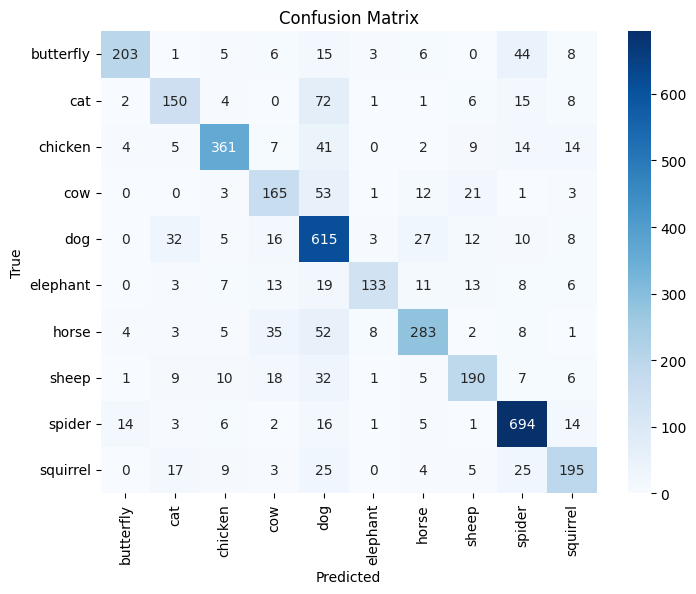

In [26]:
trainer.train(model_simple_v3_inbalanced, criterion, optimizer, learning_rate_scheduler, epochs=60)


test Accuracy: 75.92%
test Precision: 0.7682, recall: 0.7223, f1: 0.7400
test Top-1 Accuracy: 75.78%
test Top-5 Accuracy: 97.92%


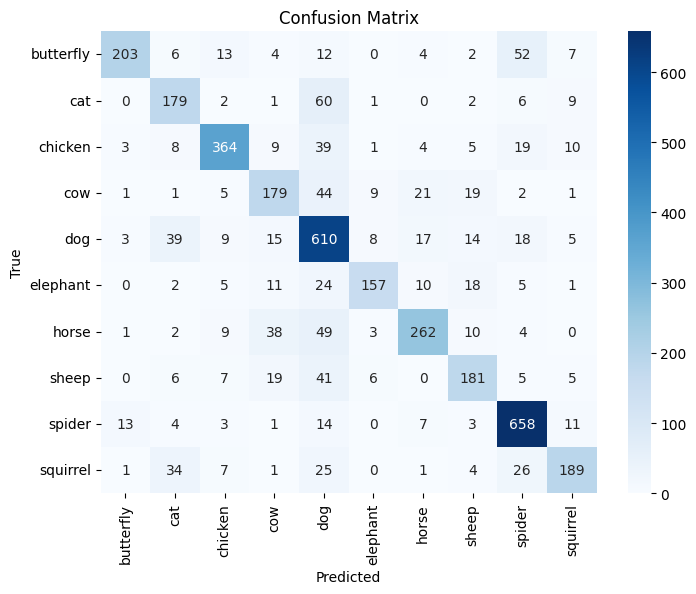

In [27]:
trainer.test(model_simple_v3_inbalanced)

In [28]:
wandb.finish()

epoch,▁▁▁▁▁▂▂▂▂▂▃▃▃▃▃▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇████
test_accuracy,▁
test_f1_score,▁
test_precision,▁
test_recall,▁
test_top1,▁
test_top5,▁
train_accuracy,▁▂▂▃▃▄▄▅▅▅▅▆▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇████████████
train_f1,▁▂▂▃▃▄▄▅▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇███████████
train_loss,█▇▇▆▆▅▅▄▄▄▄▄▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁
train_precision,▁▂▂▃▃▄▄▅▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇█████████████


## Conclusion
The best results were achieved on the oversampled dataset, which outperformed the original dataset by about 5% in most metrics.